# Proyek Akhir: Menyelesaikan Permasalahan Perusahaan Edutech

- Nama: Kadek Gary Faldi
- Email: garyfaldi1@gmail.com
- Id Dicoding: garyfaldi - M297D5Y0931

## Persiapan

### Menyiapkan library yang dibutuhkan

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay,
    accuracy_score, f1_score, precision_score, recall_score
)
import joblib
import os

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
print('Libraries loaded successfully!')

Libraries loaded successfully!


### Menyiapkan data yang akan digunakan

In [26]:
df = pd.read_csv('employee_data.csv')
print(f'Dataset shape: {df.shape}')
df.head()

Dataset shape: (1470, 35)


,EmployeeId,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,1,38,NaN,Travel_Frequently,1444,Human Resources,1,4,Other,1,...,2,80,1,7,2,3,6,2,1,2
1,2,37,1.0,Travel_Rarely,1141,Research & Development,11,2,Medical,1,...,1,80,0,15,2,1,1,0,0,0
2,3,51,1.0,Travel_Rarely,1323,Research & Development,4,4,Life Sciences,1,...,3,80,3,18,2,4,10,0,2,7
3,4,42,0.0,Travel_Frequently,555,Sales,26,3,Marketing,1,...,4,80,1,23,2,4,20,4,4,8
4,5,40,NaN,Travel_Rarely,1194,Research & Development,2,4,Medical,1,...,2,80,3,20,2,3,5,3,0,2


## Data Understanding

In [27]:
print('=== INFO DATASET ===')
df.info()
print()
print('=== STATISTIK DESKRIPTIF ===')
df.describe()

=== INFO DATASET ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   EmployeeId                1470 non-null   int64  
 1   Age                       1470 non-null   int64  
 2   Attrition                 1058 non-null   float64
 3   BusinessTravel            1470 non-null   object 
 4   DailyRate                 1470 non-null   int64  
 5   Department                1470 non-null   object 
 6   DistanceFromHome          1470 non-null   int64  
 7   Education                 1470 non-null   int64  
 8   EducationField            1470 non-null   object 
 9   EmployeeCount             1470 non-null   int64  
 10  EnvironmentSatisfaction   1470 non-null   int64  
 11  Gender                    1470 non-null   object 
 12  HourlyRate                1470 non-null   int64  
 13  JobInvolvement            1470 non-null   

,EmployeeId,Age,Attrition,DailyRate,DistanceFromHome,Education,EmployeeCount,EnvironmentSatisfaction,HourlyRate,JobInvolvement,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1058.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,735.500000,36.923810,0.169187,802.485714,9.192517,2.912925,1.0,2.721769,65.891156,2.729932,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,424.496761,9.135373,0.375094,403.509100,8.106864,1.024165,0.0,1.093082,20.329428,0.711561,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,1.000000,18.000000,0.000000,102.000000,1.000000,1.000000,1.0,1.000000,30.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,368.250000,30.000000,0.000000,465.000000,2.000000,2.000000,1.0,2.000000,48.000000,2.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,735.500000,36.000000,0.000000,802.000000,7.000000,3.000000,1.0,3.000000,66.000000,3.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,1102.750000,43.000000,0.000000,1157.000000,14.000000,4.000000,1.0,4.000000,83.750000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,1470.000000,60.000000,1.000000,1499.000000,29.000000,5.000000,1.0,4.000000,100.000000,4.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [28]:
print('=== MISSING VALUES ===')
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else 'Tidak ada missing values!')
print(f'\nJumlah duplikat: {df.duplicated().sum()}')

=== MISSING VALUES ===
Attrition    412
dtype: int64

Jumlah duplikat: 0


=== DISTRIBUSI ATTRITION ===
           Count  Percentage (%)
Attrition                       
0.0          879           83.08
1.0          179           16.92


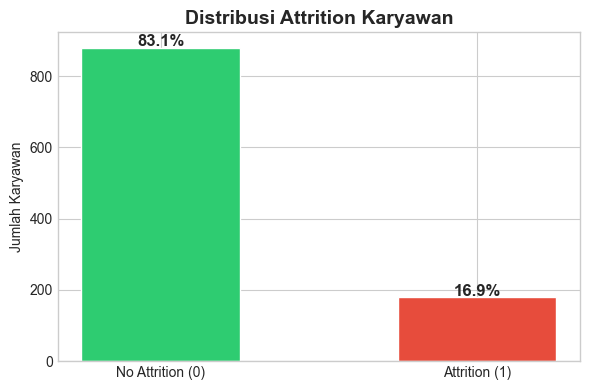

In [ ]:
attrition_count = df['Attrition'].value_counts()
attrition_pct   = df['Attrition'].value_counts(normalize=True) * 100

print('=== DISTRIBUSI ATTRITION ===')
print(pd.DataFrame({'Count': attrition_count, 'Percentage (%)': attrition_pct.round(2)}))

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(['No Attrition (0)', 'Attrition (1)'], attrition_count.values,
              color=['#2ecc71', '#e74c3c'], edgecolor='white', width=0.5)
for bar, pct in zip(bars, attrition_pct.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            f'{pct:.1f}%', ha='center', fontweight='bold', fontsize=12)
ax.set_title('Distribusi Attrition Karyawan', fontsize=14, fontweight='bold')
ax.set_ylabel('Jumlah Karyawan')
plt.tight_layout()
plt.savefig('charts/attrition_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

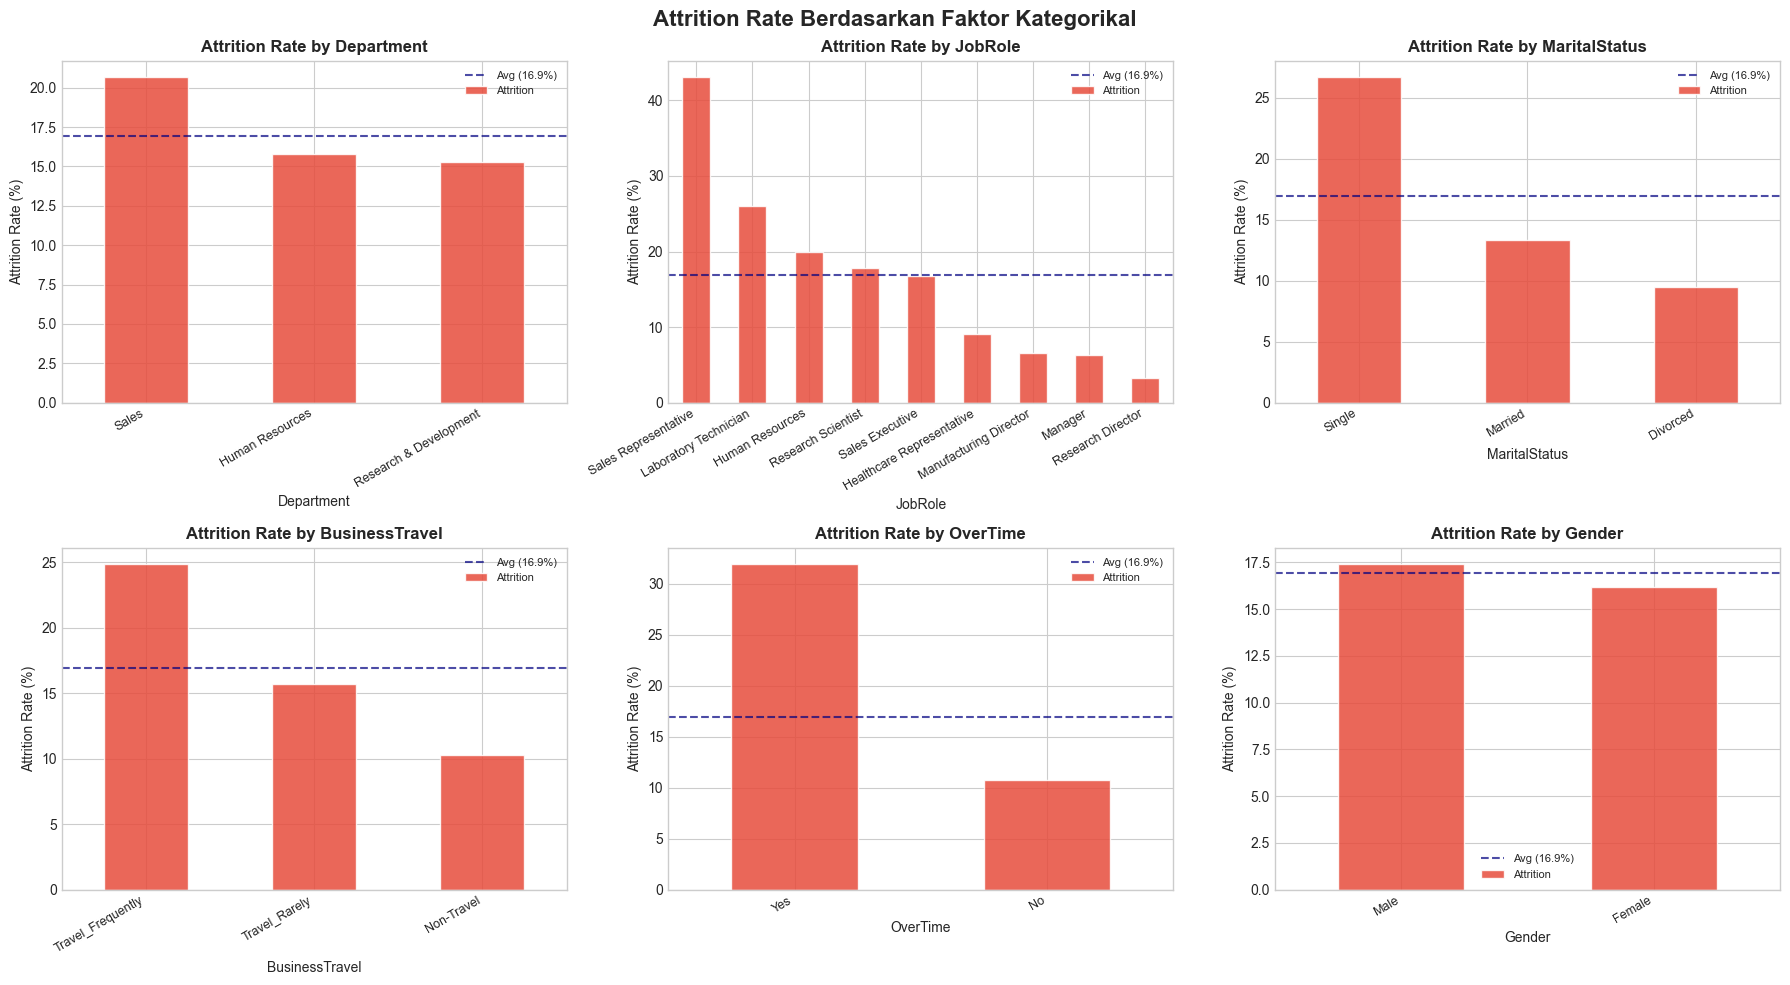

In [ ]:
cat_cols = ['Department', 'JobRole', 'MaritalStatus', 'BusinessTravel', 'OverTime', 'Gender']
avg_attrition = df['Attrition'].mean() * 100

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    cross = df.groupby(col)['Attrition'].mean() * 100
    cross.sort_values(ascending=False).plot(
        kind='bar', ax=axes[i], color='#e74c3c', edgecolor='white', alpha=0.85
    )
    axes[i].set_title(f'Attrition Rate by {col}', fontweight='bold')
    axes[i].set_ylabel('Attrition Rate (%)')
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=30, ha='right', fontsize=9)
    axes[i].axhline(y=avg_attrition, color='navy', linestyle='--', alpha=0.7,
                    label=f'Avg ({avg_attrition:.1f}%)')
    axes[i].legend(fontsize=8)

plt.suptitle('Attrition Rate Berdasarkan Faktor Kategorikal', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('charts/attrition_categorical.png', dpi=150, bbox_inches='tight')
plt.show()

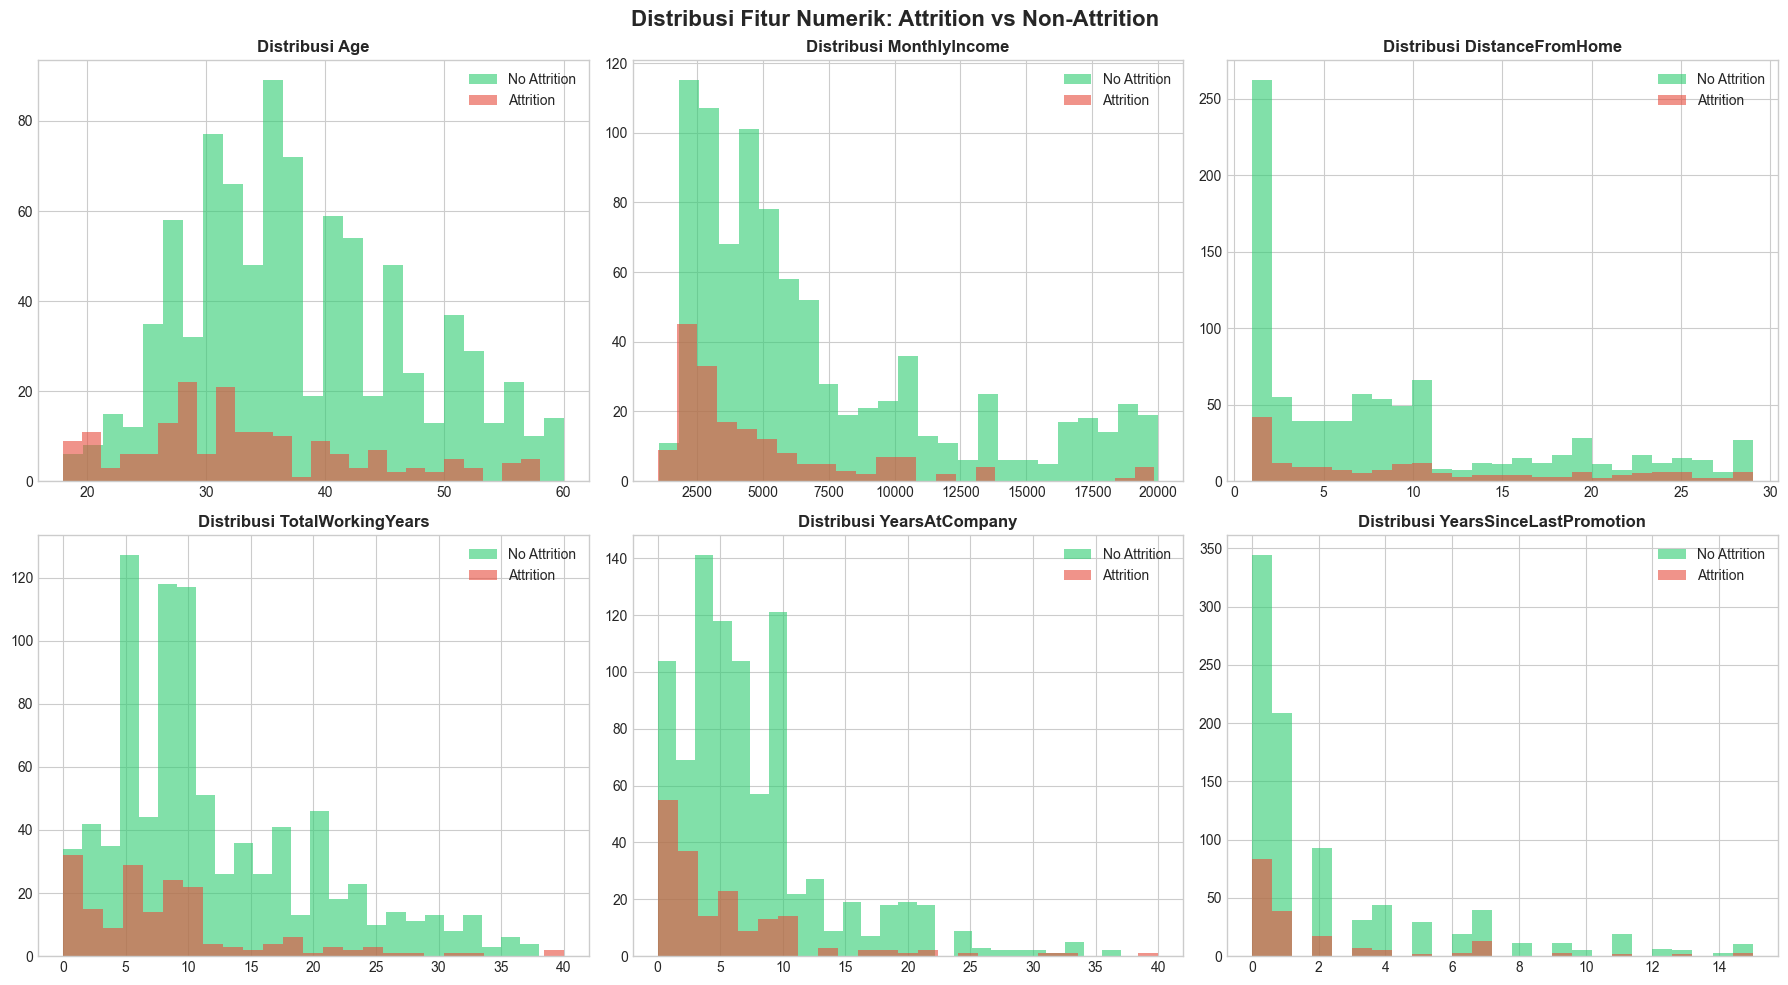

In [ ]:
num_cols = ['Age', 'MonthlyIncome', 'DistanceFromHome',
            'TotalWorkingYears', 'YearsAtCompany', 'YearsSinceLastPromotion']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    df[df['Attrition']==0][col].hist(ax=axes[i], bins=25, alpha=0.6,
                                     color='#2ecc71', label='No Attrition')
    df[df['Attrition']==1][col].hist(ax=axes[i], bins=25, alpha=0.6,
                                     color='#e74c3c', label='Attrition')
    axes[i].set_title(f'Distribusi {col}', fontweight='bold')
    axes[i].legend()

plt.suptitle('Distribusi Fitur Numerik: Attrition vs Non-Attrition', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('charts/attrition_numerical.png', dpi=150, bbox_inches='tight')
plt.show()

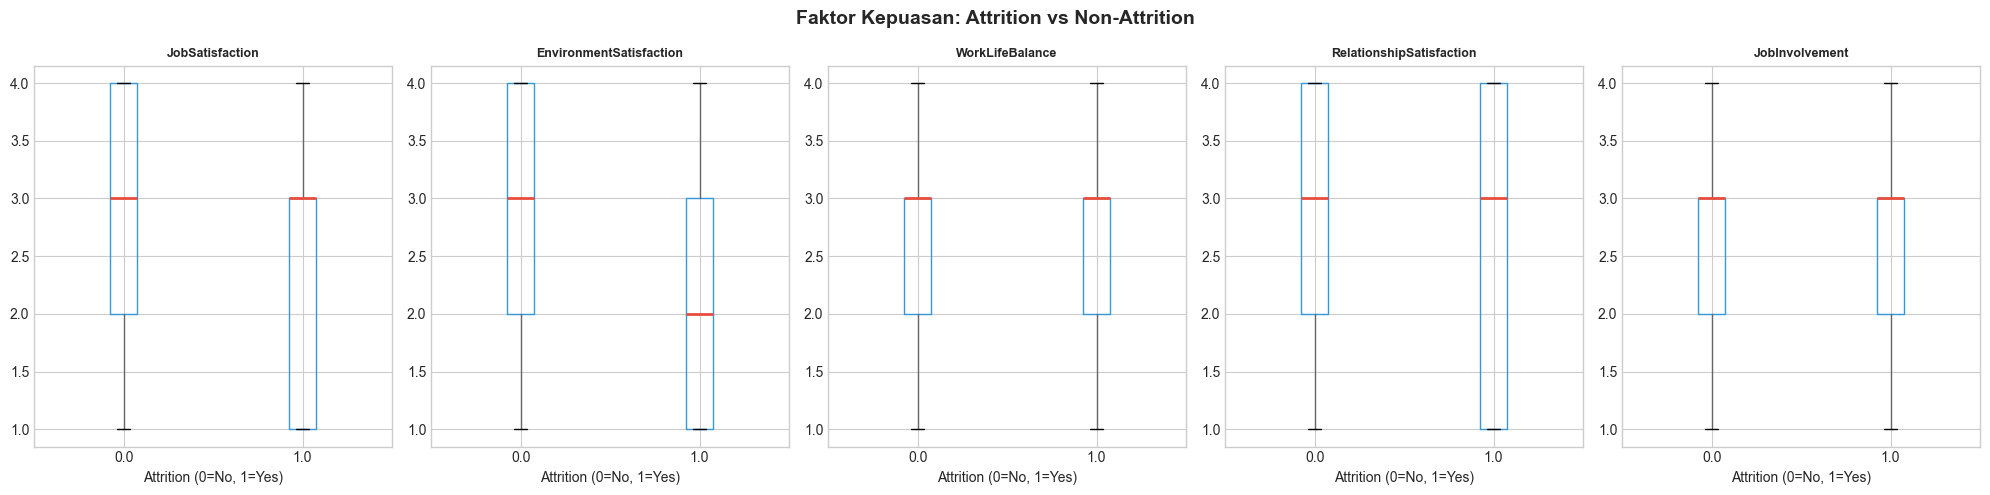

In [ ]:
sat_cols = ['JobSatisfaction', 'EnvironmentSatisfaction', 'WorkLifeBalance',
            'RelationshipSatisfaction', 'JobInvolvement']

fig, axes = plt.subplots(1, 5, figsize=(20, 5))
for i, col in enumerate(sat_cols):
    df.boxplot(column=col, by='Attrition', ax=axes[i],
               boxprops=dict(color='#3498db'),
               medianprops=dict(color='#e74c3c', linewidth=2))
    axes[i].set_title(col, fontweight='bold', fontsize=9)
    axes[i].set_xlabel('Attrition (0=No, 1=Yes)')

plt.suptitle('Faktor Kepuasan: Attrition vs Non-Attrition', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('charts/satisfaction_factors.png', dpi=150, bbox_inches='tight')
plt.show()

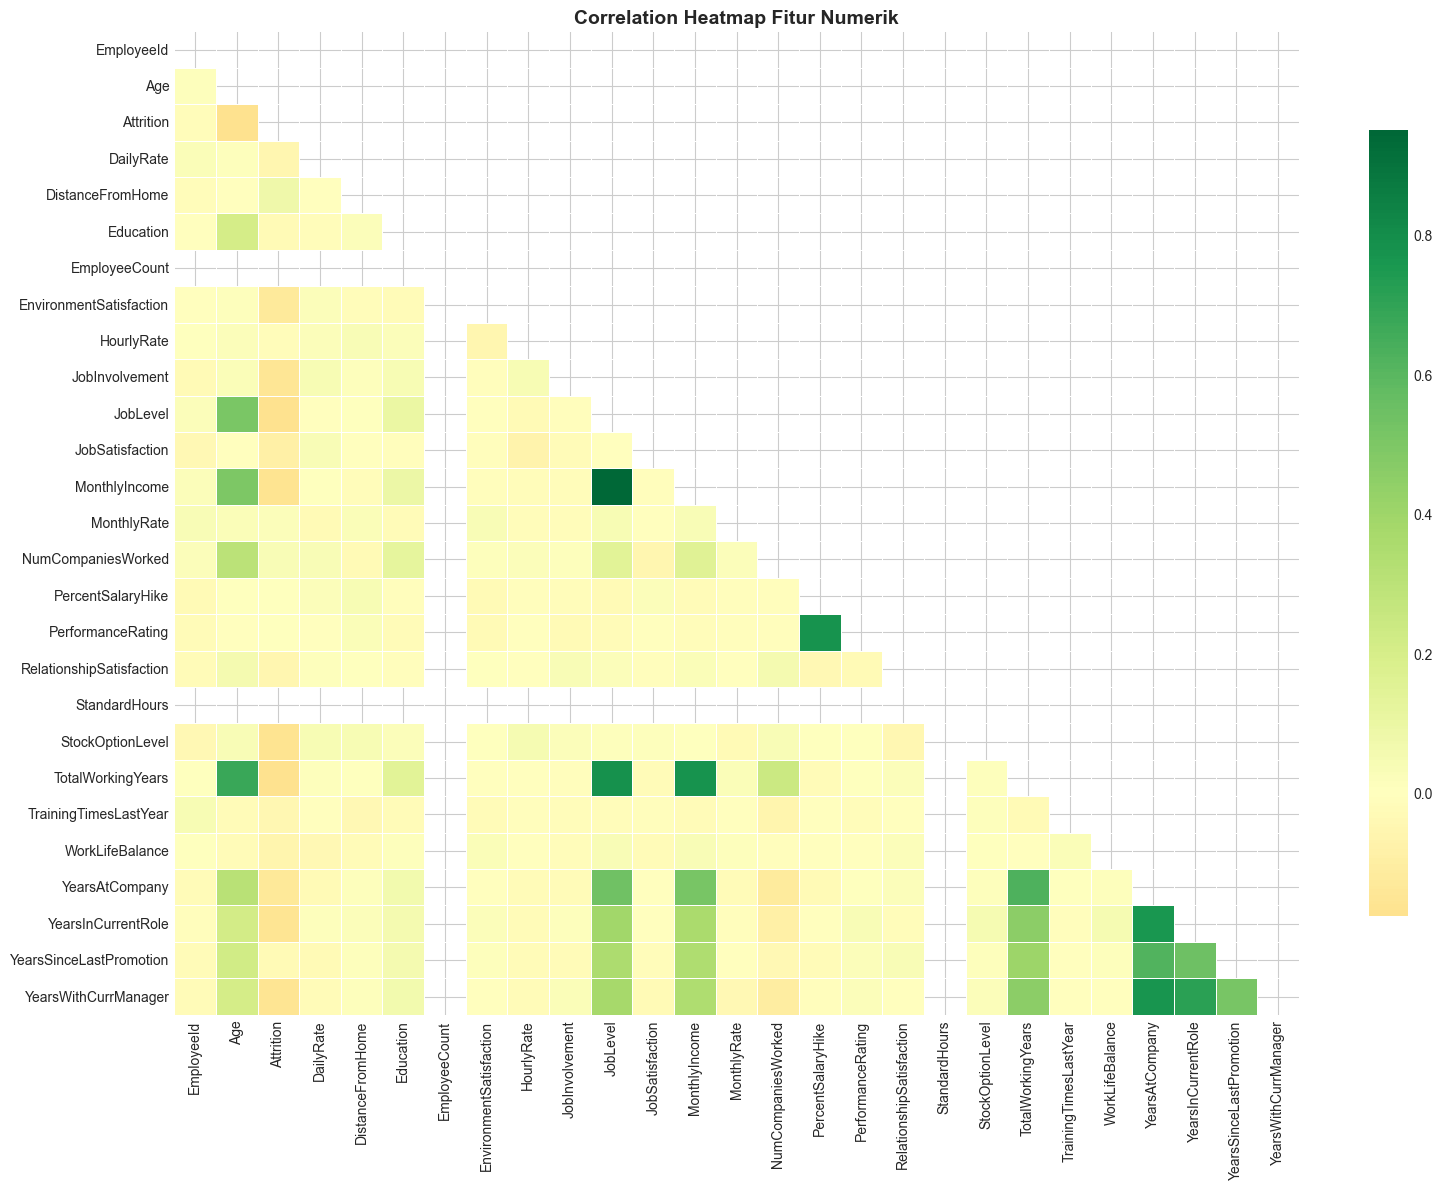

In [ ]:
num_df = df.select_dtypes(include='number')
corr = num_df.corr()

plt.figure(figsize=(16, 12))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=False, cmap='RdYlGn',
            center=0, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Correlation Heatmap Fitur Numerik', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('charts/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## Data Preparation / Preprocessing

In [ ]:
df_clean = df.copy()

cols_to_drop = ['EmployeeId', 'Over18', 'StandardHours']
cols_to_drop = [c for c in cols_to_drop if c in df_clean.columns]
df_clean.drop(columns=cols_to_drop, inplace=True)
print(f'Kolom dihapus: {cols_to_drop}')

Kolom dihapus: ['EmployeeId', 'Over18', 'StandardHours']


In [ ]:
cat_columns = df_clean.select_dtypes(include='object').columns.tolist()
print(f'Kolom kategorikal: {cat_columns}')

label_encoders = {}
for col in cat_columns:
    le = LabelEncoder()
    df_clean[col] = le.fit_transform(df_clean[col].astype(str))
    label_encoders[col] = le

print('Label encoding selesai!')
df_clean.head()

Kolom kategorikal: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']
Label encoding selesai!


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EnvironmentSatisfaction,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,38,NaN,1,1444,0,1,4,4,1,4,...,3,2,1,7,2,3,6,2,1,2
1,37,1.0,2,1141,1,11,2,3,1,1,...,3,1,0,15,2,1,1,0,0,0
2,51,1.0,2,1323,1,4,4,1,1,1,...,3,3,3,18,2,4,10,0,2,7
3,42,0.0,1,555,2,26,3,2,1,3,...,3,4,1,23,2,4,20,4,4,8
4,40,NaN,2,1194,1,2,4,3,1,3,...,3,2,3,20,2,3,5,3,0,2


In [ ]:
print(f'NaN sebelum cleaning: {df_clean.isnull().sum().sum()}')

df_clean = df_clean.dropna(subset=['Attrition'])

num_cols_clean = df_clean.select_dtypes(include='number').columns
cat_cols_clean = df_clean.select_dtypes(include='object').columns
df_clean[num_cols_clean] = df_clean[num_cols_clean].fillna(df_clean[num_cols_clean].median())
for col in cat_cols_clean:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

print(f'NaN setelah cleaning : {df_clean.isnull().sum().sum()}')
print(f'Total rows setelah cleaning: {len(df_clean)}')

df_clean['Attrition'] = df_clean['Attrition'].astype(int)

NaN sebelum cleaning: 412
NaN setelah cleaning : 0
Total rows setelah cleaning: 1058


In [ ]:
X = df_clean.drop(columns=['Attrition'])
y = df_clean['Attrition']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f'Train size : {X_train.shape}')
print(f'Test size  : {X_test.shape}')
print(f'Class dist (train) — 0: {(y_train==0).sum()}, 1: {(y_train==1).sum()}')

Train size : (846, 31)
Test size  : (212, 31)
Class dist (train) — 0: 703, 1: 143


## Modeling

In [ ]:
neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
scale_pos_weight = neg / pos
print(f'scale_pos_weight untuk XGBoost: {scale_pos_weight:.2f}')

models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, class_weight='balanced', random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, max_depth=10, min_samples_split=5,
        class_weight='balanced', random_state=42, n_jobs=-1
    ),
    'XGBoost': XGBClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.05,
        scale_pos_weight=scale_pos_weight,
        eval_metric='logloss', random_state=42, n_jobs=-1
    )
}

print('Model definitions ready!')

scale_pos_weight untuk XGBoost: 4.92
Model definitions ready!


In [ ]:
trained_models = {}
results = {}

for name, model in models.items():
    print(f'Training {name}...')
    model.fit(X_train_scaled, y_train)
    trained_models[name] = model

    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]

    results[name] = {
        'accuracy' : accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, zero_division=0),
        'recall'   : recall_score(y_test, y_pred, zero_division=0),
        'f1'       : f1_score(y_test, y_pred, zero_division=0),
        'roc_auc'  : roc_auc_score(y_test, y_prob),
        'y_pred'   : y_pred,
        'y_prob'   : y_prob
    }
    print(f'  ROC-AUC: {results[name]["roc_auc"]:.4f} | F1: {results[name]["f1"]:.4f}\n')

print('Semua model selesai ditraining!')

Training Logistic Regression...
  ROC-AUC: 0.8038 | F1: 0.5045

Training Random Forest...
  ROC-AUC: 0.7748 | F1: 0.3478

Training XGBoost...
  ROC-AUC: 0.7740 | F1: 0.4478

Semua model selesai ditraining!


## Evaluation

In [ ]:
metrics_df = pd.DataFrame({
    name: {
        'Accuracy' : round(v['accuracy'], 4),
        'Precision': round(v['precision'], 4),
        'Recall'   : round(v['recall'], 4),
        'F1-Score' : round(v['f1'], 4),
        'ROC-AUC'  : round(v['roc_auc'], 4)
    }
    for name, v in results.items()
}).T

print('=== PERBANDINGAN PERFORMA MODEL ===')
print(metrics_df.to_string())
print(f'\nBest model (ROC-AUC): {metrics_df["ROC-AUC"].idxmax()}')
print(f'Best model (F1-Score): {metrics_df["F1-Score"].idxmax()}')

=== PERBANDINGAN PERFORMA MODEL ===
                     Accuracy  Precision  Recall  F1-Score  ROC-AUC
Logistic Regression    0.7406     0.3733  0.7778    0.5045   0.8038
Random Forest          0.8585     0.8000  0.2222    0.3478   0.7748
XGBoost                0.8255     0.4839  0.4167    0.4478   0.7740

Best model (ROC-AUC): Logistic Regression
Best model (F1-Score): Logistic Regression


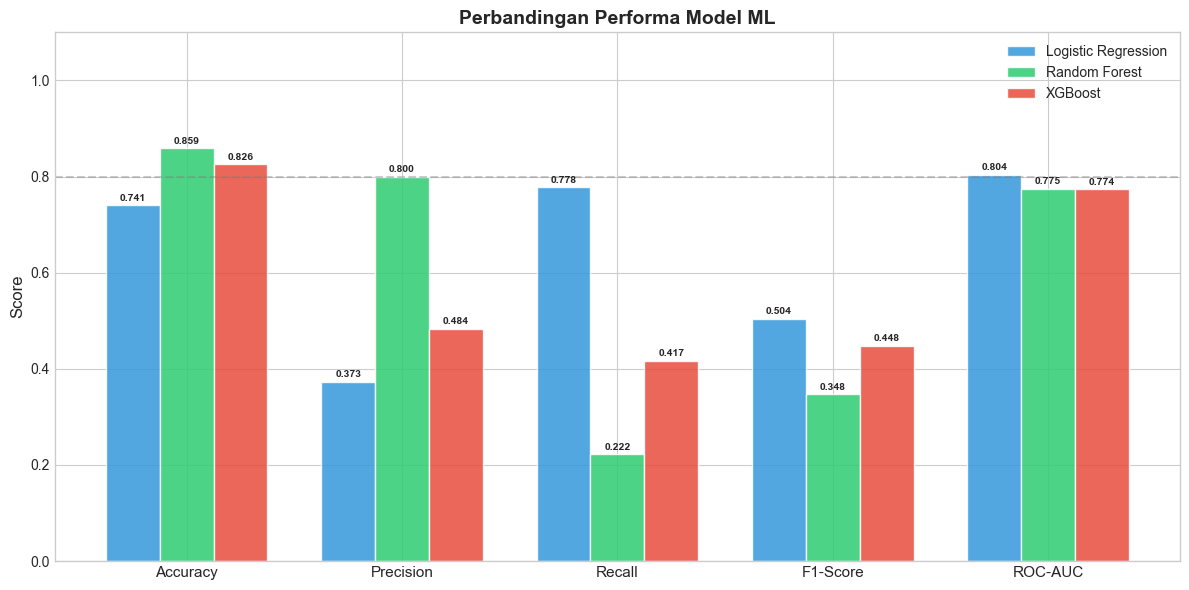

In [41]:
# Bar chart perbandingan semua metrik
metrics_plot = metrics_df[['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']]
x = np.arange(len(metrics_plot.columns))
width = 0.25
colors = ['#3498db', '#2ecc71', '#e74c3c']

fig, ax = plt.subplots(figsize=(12, 6))
for i, (model_name, row) in enumerate(metrics_plot.iterrows()):
    bars = ax.bar(x + i*width, row.values, width, label=model_name,
                  color=colors[i], alpha=0.85, edgecolor='white')
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{bar.get_height():.3f}', ha='center', va='bottom',
                fontsize=7.5, fontweight='bold')

ax.set_xticks(x + width)
ax.set_xticklabels(metrics_plot.columns, fontsize=11)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Perbandingan Performa Model ML', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.axhline(0.8, color='gray', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('charts/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

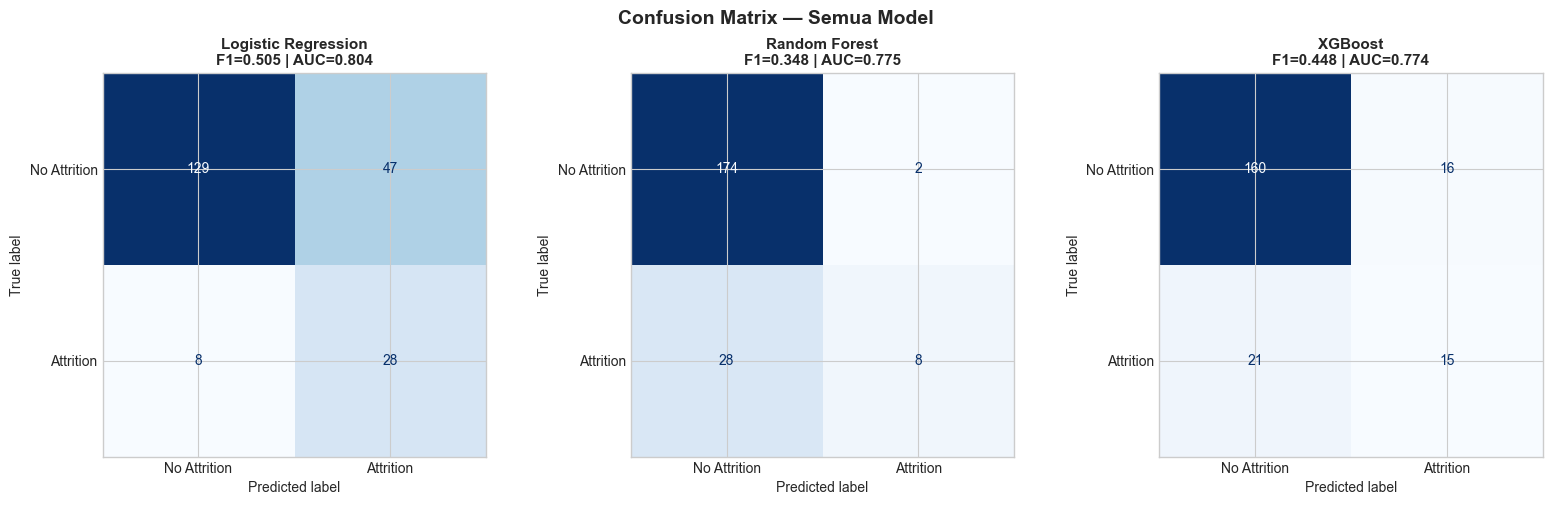

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=['No Attrition', 'Attrition'])
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'{name}\nF1={res["f1"]:.3f} | AUC={res["roc_auc"]:.3f}',
                 fontweight='bold', fontsize=11)

plt.suptitle('Confusion Matrix — Semua Model', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('charts/confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

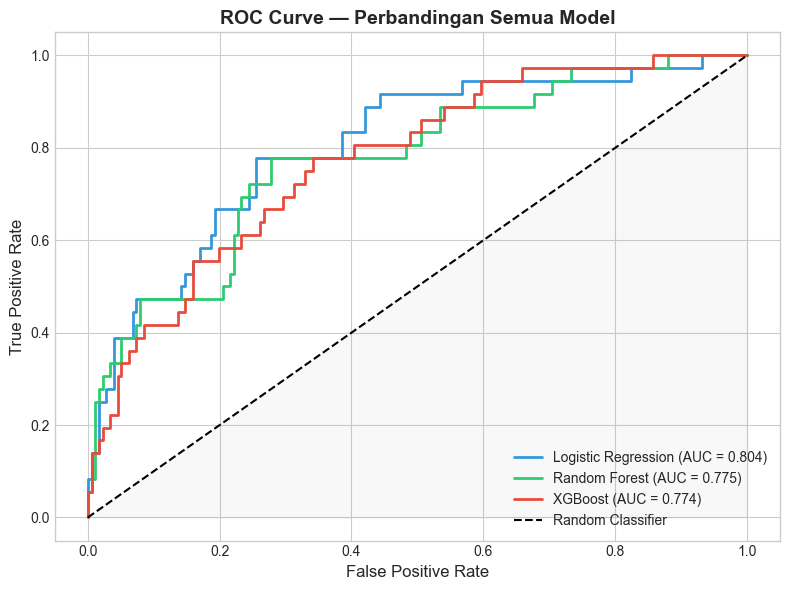

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
colors_roc = ['#3498db', '#2ecc71', '#e74c3c']

for (name, res), color in zip(results.items(), colors_roc):
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    ax.plot(fpr, tpr, color=color, lw=2,
            label=f'{name} (AUC = {res["roc_auc"]:.3f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Classifier')
ax.fill_between([0, 1], [0, 1], alpha=0.05, color='gray')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curve — Perbandingan Semua Model', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
plt.tight_layout()
plt.savefig('charts/roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

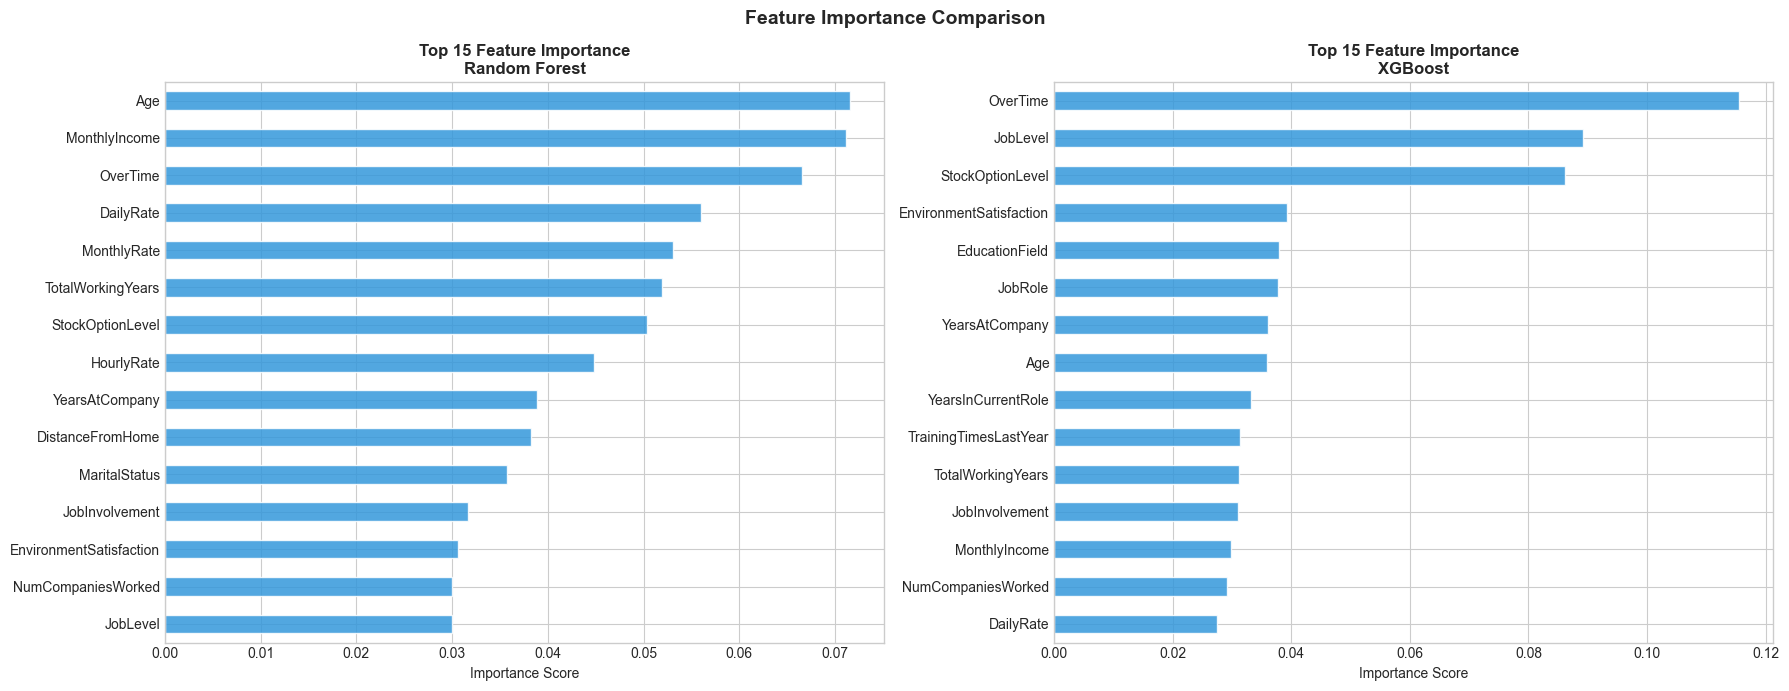

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, model_name in zip(axes, ['Random Forest', 'XGBoost']):
    importance = pd.Series(
        trained_models[model_name].feature_importances_,
        index=X.columns
    )
    importance.sort_values(ascending=False).head(15).plot(
        kind='barh', ax=ax, color='#3498db', edgecolor='white', alpha=0.85
    )
    ax.set_title(f'Top 15 Feature Importance\n{model_name}', fontweight='bold', fontsize=12)
    ax.set_xlabel('Importance Score')
    ax.invert_yaxis()

plt.suptitle('Feature Importance Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('charts/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
best_model_name = metrics_df['ROC-AUC'].idxmax()
best_result     = results[best_model_name]

print(f'=== CLASSIFICATION REPORT: {best_model_name.upper()} (BEST MODEL) ===')
print(classification_report(y_test, best_result['y_pred'],
                            target_names=['No Attrition', 'Attrition']))

=== CLASSIFICATION REPORT: LOGISTIC REGRESSION (BEST MODEL) ===
              precision    recall  f1-score   support

No Attrition       0.94      0.73      0.82       176
   Attrition       0.37      0.78      0.50        36

    accuracy                           0.74       212
   macro avg       0.66      0.76      0.66       212
weighted avg       0.85      0.74      0.77       212



In [ ]:
os.makedirs('models', exist_ok=True)

best_model = trained_models[best_model_name]
joblib.dump(best_model,             'models/best_model.pkl')
joblib.dump(scaler,                 'models/scaler.pkl')
joblib.dump(label_encoders,         'models/label_encoders.pkl')
joblib.dump(X.columns.tolist(),     'models/feature_names.pkl')

for name, model in trained_models.items():
    safe = name.lower().replace(' ', '_')
    joblib.dump(model, f'models/{safe}.pkl')

print(f'Best model : {best_model_name} -> models/best_model.pkl')

Best model : Logistic Regression -> models/best_model.pkl


In [ ]:
import sqlite3
df_clean['Attrition'] = df['Attrition'].map({1: 'Yes', 0: 'No'})
df_clean.to_csv('employee_data_clean.csv', index=False)
print(f'Data exported: employee_data_clean.csv ({len(df_clean)} rows)')

conn = sqlite3.connect('jaya_jaya_maju.db')
df_clean.to_sql('attrition_table', conn, if_exists='replace', index=False)
conn.close()

Data exported: employee_data_clean.csv (1058 rows)
